In [1]:
import numpy as np
from oneargopy.OneArgo import Argo
from argopy import DataFetcher as ArgoDataFetcher
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw

## Reading new and old .csv's in

In [5]:
df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv')
df_old = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_School_Year/old_AAR_BGC_extended_region_alltime.csv')

/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_11333/498635473.py:1: DtypeWarning: Columns (0: LATITUDE, 1: LONGITUDE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv')
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_11333/498635473.py:2: DtypeWarning: Columns (0: LATITUDE, 1: LONGITUDE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_old = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_School_Year/old_AAR_BGC_extended_region_alltime.csv')


In [6]:
df_new

,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,PRES,...,NITRATE,NITRATE_QC,NITRATE_ADJUSTED,NITRATE_ADJUSTED_QC,NITRATE_ADJUSTED_ERROR,PH_IN_SITU_TOTAL,PH_IN_SITU_TOTAL_QC,PH_IN_SITU_TOTAL_ADJUSTED,PH_IN_SITU_TOTAL_ADJUSTED_QC,PH_IN_SITU_TOTAL_ADJUSTED_ERROR
0,0,1901135,1,A,2008-11-26 23:49:02.000028,1,-43.984,72.376,1,6.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1901135,1,A,2008-11-26 23:49:02.000028,1,-43.984,72.376,1,10.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1901135,1,A,2008-11-26 23:49:02.000028,1,-43.984,72.376,1,15.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1901135,1,A,2008-11-26 23:49:02.000028,1,-43.984,72.376,1,20.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1901135,1,A,2008-11-26 23:49:02.000028,1,-43.984,72.376,1,25.40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6451529,6451529,7902379,14,A,2026-07-01 10:03:43.001077,1,-56.6351,162.8415,1,1799.36,...,38.563477,3.0,31.414875,1.0,1.360975,7.859348,3.0,7.862852,1.0,1.324442
6451530,6451530,7902379,14,A,2026-07-01 10:03:43.001077,1,-56.6351,162.8415,1,1848.96,...,38.723770,3.0,31.575170,1.0,1.361217,7.857779,3.0,7.861282,1.0,1.324683
6451531,6451531,7902379,14,A,2026-07-01 10:03:43.001077,1,-56.6351,162.8415,1,1899.18,...,38.866090,3.0,31.717491,1.0,1.361617,7.857608,3.0,7.861112,1.0,1.325084
6451532,6451532,7902379,14,A,2026-07-01 10:03:43.001077,1,-56.6351,162.8415,1,1948.72,...,38.840120,3.0,31.691519,1.0,1.362013,7.856983,3.0,7.860488,1.0,1.325480


In [7]:
df_old

,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,PRES,...,NITRATE,NITRATE_QC,NITRATE_ADJUSTED,NITRATE_ADJUSTED_QC,NITRATE_ADJUSTED_ERROR,PH_IN_SITU_TOTAL,PH_IN_SITU_TOTAL_QC,PH_IN_SITU_TOTAL_ADJUSTED,PH_IN_SITU_TOTAL_ADJUSTED_QC,PH_IN_SITU_TOTAL_ADJUSTED_ERROR
0,0,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,6.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,14.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,19.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,24.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1519016,1519016,7902154,16,A,2025-10-16 06:34:24.000693,1,-58.1553,174.3372,1,1600.10,...,32.842896,3.0,33.114273,1.0,1.311489,7.856922,3.0,7.838748,1.0,0.014984
1519017,1519017,7902154,16,A,2025-10-16 06:34:24.000693,1,-58.1553,174.3372,1,1699.80,...,32.520950,3.0,32.792328,1.0,1.311867,7.858857,3.0,7.840679,1.0,0.014990
1519018,1519018,7902154,16,A,2025-10-16 06:34:24.000693,1,-58.1553,174.3372,1,1799.52,...,32.327694,3.0,32.599070,1.0,1.312243,7.861394,3.0,7.843212,1.0,0.014996
1519019,1519019,7902154,16,A,2025-10-16 06:34:24.000693,1,-58.1553,174.3372,1,1900.15,...,31.881544,3.0,32.152920,1.0,1.312737,7.864672,3.0,7.846485,1.0,0.015004


## New data WMOIDs - no longer accurate, from old new data (tried downloading and re-downloaded
3902129 - NaNs


5905375 - 1 measurement near surface, NaNs, then 1000-2000 m

5905379 - 1 measurement near surface, NaNs, then 1000-2000 m

5905555 - full depth column

5906581 - 1 measurement near surface, NaNs, then 1000-2000 m

5906582 - 1 measurement near surface, NaNs, then 1000-2000 m

5906583 - 1 measurement near surface, NaNs, then 1000-2000 m

6902885 - NaNs

6902891 - NaNs

## New data is mostly NaNs and some data at depth (1000-2000 m)

Floats that have at least some data not just NaNs: 5903630, 5903717, 5904105, 5904179, 5904676, 5904677, 5904682, 5904688, 5905099, 5905100, 5905101, 5905102, 5905103, 5905372, 5905373, 5905374, 5905375, 5905376, 5905377, 5905379, 5905396 (lots), 5905555 (lots), 5905556 (lots), 5905638, 5906207, 5906442, 5906509 (lots), 5906581, 5906582, 5906583, 5906624, 6901004 (lots), 6990587, 7902154, 7902155, 7902379 (all  new, lots)

In [287]:
WMOIDS_new = df_new['WMOID'].unique().tolist()
WMOIDS_new

[1901135,
 1901155,
 1901157,
 1902662,
 2903454,
 5900345,
 5901178,
 5901645,
 5901648,
 5901698,
 5901699,
 5903242,
 5903248,
 5903260,
 5903630,
 5903717,
 5903719,
 5903720,
 5903721,
 5903722,
 5903723,
 5903939,
 5904104,
 5904105,
 5904179,
 5904481,
 5904482,
 5904483,
 5904598,
 5904599,
 5904676,
 5904677,
 5904682,
 5904688,
 5905096,
 5905097,
 5905098,
 5905099,
 5905100,
 5905101,
 5905102,
 5905103,
 5905232,
 5905372,
 5905373,
 5905374,
 5905375,
 5905376,
 5905377,
 5905379,
 5905396,
 5905555,
 5905556,
 5905557,
 5905638,
 5906207,
 5906221,
 5906442,
 5906509,
 5906581,
 5906582,
 5906583,
 5906624,
 6901004,
 6902885,
 6902891,
 6903190,
 6903233,
 6903768,
 6903777,
 6990587,
 7902154,
 7902155,
 7902379]

In [9]:
WMOIDS_old = df_old['WMOID'].unique().tolist()
WMOIDS_old

[1901135,
 1901153,
 1901155,
 1901157,
 1902662,
 2903454,
 3902129,
 5900345,
 5901178,
 5901645,
 5901648,
 5901698,
 5901699,
 5903242,
 5903248,
 5903260,
 5903630,
 5903717,
 5903719,
 5903720,
 5903721,
 5903722,
 5903723,
 5903939,
 5904104,
 5904105,
 5904179,
 5904481,
 5904482,
 5904483,
 5904598,
 5904599,
 5904676,
 5904677,
 5904682,
 5904688,
 5905096,
 5905097,
 5905098,
 5905099,
 5905100,
 5905101,
 5905102,
 5905103,
 5905232,
 5905372,
 5905373,
 5905374,
 5905375,
 5905376,
 5905377,
 5905379,
 5905396,
 5905555,
 5905556,
 5905557,
 5905638,
 5906207,
 5906221,
 5906442,
 5906509,
 5906581,
 5906582,
 5906583,
 5906624,
 6901004,
 6902814,
 6902885,
 6902891,
 6903190,
 6903233,
 6903768,
 6990587,
 7902154]

## Testing full float data not cycle by cycle

In [307]:
comp_old

,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,PRES,...,NITRATE,NITRATE_QC,NITRATE_ADJUSTED,NITRATE_ADJUSTED_QC,NITRATE_ADJUSTED_ERROR,PH_IN_SITU_TOTAL,PH_IN_SITU_TOTAL_QC,PH_IN_SITU_TOTAL_ADJUSTED,PH_IN_SITU_TOTAL_ADJUSTED_QC,PH_IN_SITU_TOTAL_ADJUSTED_ERROR
341581,341581,5904104,22,A,2013-06-21 10:27:40.001112,1,-64.077,150.017,8,4.2,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
341582,341582,5904104,22,A,2013-06-21 10:27:40.001112,1,-64.077,150.017,8,6.0,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
341583,341583,5904104,22,A,2013-06-21 10:27:40.001112,1,-64.077,150.017,8,7.7,...,30.003489,3.0,31.566458,1.0,1.348274,NaN,NaN,NaN,NaN,NaN
341584,341584,5904104,22,A,2013-06-21 10:27:40.001112,1,-64.077,150.017,8,8.0,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
341585,341585,5904104,22,A,2013-06-21 10:27:40.001112,1,-64.077,150.017,8,10.0,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433399,433399,5904104,190,A,2016-07-24 22:50:33.002433,1,-62.866,179.903,1,974.0,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
433400,433400,5904104,190,A,2016-07-24 22:50:33.002433,1,-62.866,179.903,1,976.0,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
433401,433401,5904104,190,A,2016-07-24 22:50:33.002433,1,-62.866,179.903,1,978.0,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
433402,433402,5904104,190,A,2016-07-24 22:50:33.002433,1,-62.866,179.903,1,979.1,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [312]:
comp_new = df_new.loc[df_new['WMOID'] == 1901135]
comp_old = df_old.loc[df_old['WMOID'] == 1901135]
# comp_new
# comp_old

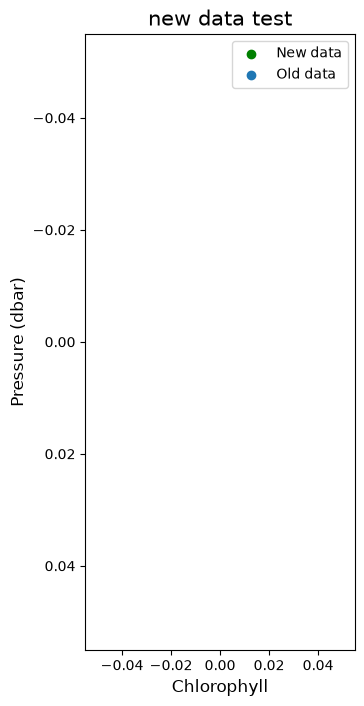

In [313]:
# WMOID 5905374

fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(141)
ax.scatter(comp_new['CHLA'], comp_new['PRES_ADJUSTED'], c ='g', label ='New data')
ax.scatter(comp_old['CHLA'], comp_old['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
# ax.set_xlim(-0.1, 1.5)
# ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('new data test',  fontsize =15)
ax.legend()

In [290]:
comp_new['CYCLE_NUMBER'].unique().tolist()

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127]

## Chlorophyll comparison new and old data cycle by cycle

## WMOID 5905555

In [30]:
comp_new = df_new.loc[df_new['WMOID'] == 5905555]
comp_old = df_old.loc[df_old['WMOID'] == 5905555]
# comp_new
# comp_old

In [31]:
new1 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 55]
old1 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 55]

new2 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 57]
old2 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 57]

new3 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 60]
old3 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 60]

new4 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 63]
old4 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 63]

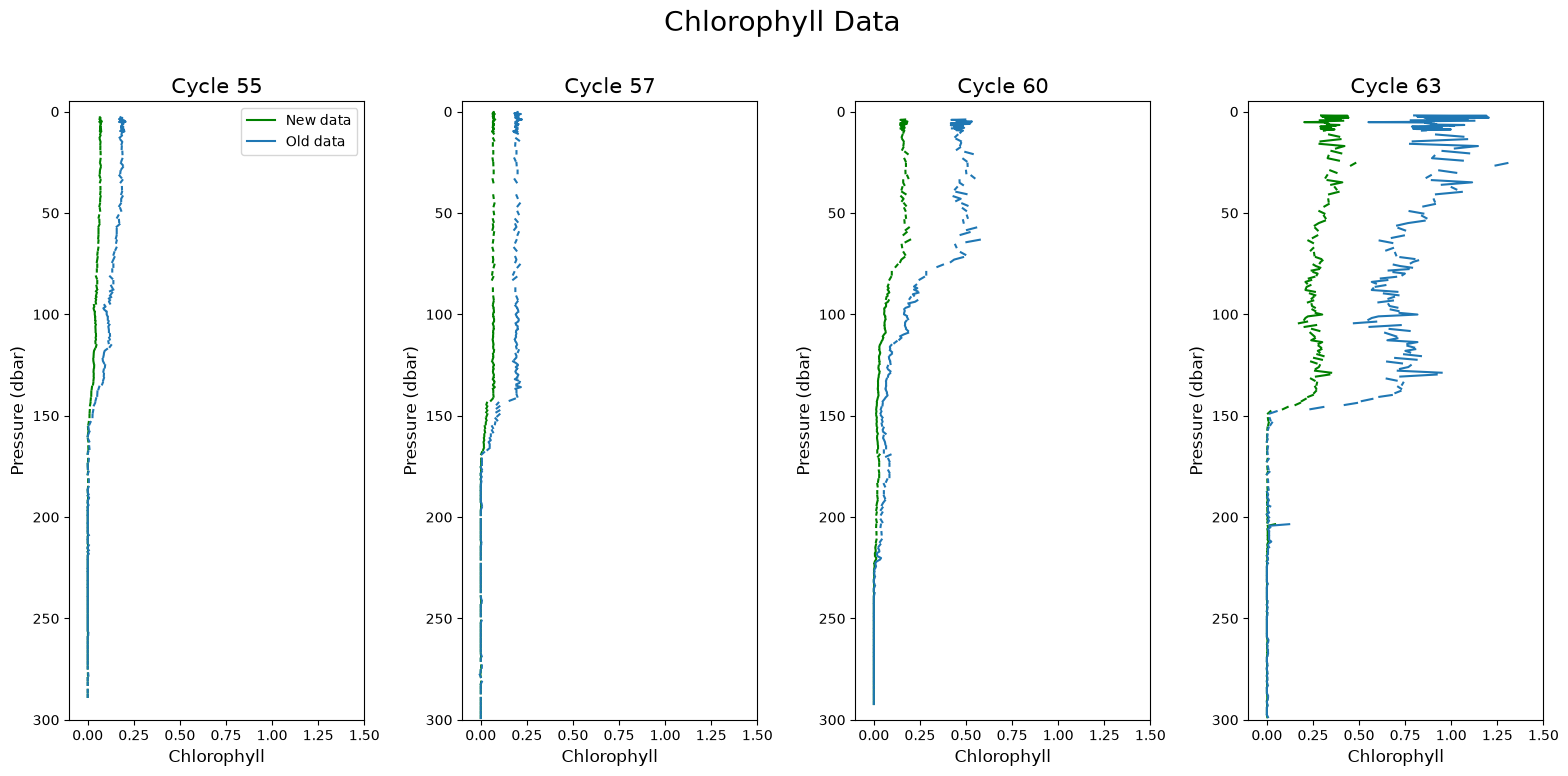

In [32]:
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(141)
ax.plot(new1['CHLA_ADJUSTED'], new1['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old1['CHLA_ADJUSTED'], old1['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 55',  fontsize =15)
ax.legend()

ax = fig.add_subplot(142)
ax.plot(new2['CHLA_ADJUSTED'], new2['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old2['CHLA_ADJUSTED'], old2['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 57',  fontsize =15)

ax = fig.add_subplot(143)
ax.plot(new3['CHLA_ADJUSTED'], new3['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old3['CHLA_ADJUSTED'], old3['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 60',  fontsize =15)

ax = fig.add_subplot(144)
ax.plot(new4['CHLA_ADJUSTED'], new4['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old4['CHLA_ADJUSTED'], old4['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 63', fontsize =15)

fig.suptitle('Chlorophyll Data', fontsize = 20)
plt.tight_layout(pad=2)


## WMOID finding another

In [131]:
comp_new = df_new.loc[df_new['WMOID'] == 5901645]
comp_old = df_old.loc[df_old['WMOID'] == 5901645]
# comp_new
# comp_old

In [132]:
comp_new['CHLA_ADJUSTED']

186948   NaN
186949   NaN
186950   NaN
186951   NaN
186952   NaN
          ..
210465   NaN
210466   NaN
210467   NaN
210468   NaN
210469   NaN
Name: CHLA_ADJUSTED, Length: 23522, dtype: float64

In [107]:
comp_old['CHLA_ADJUSTED']

Series([], Name: CHLA_ADJUSTED, dtype: float64)

In [108]:
comp_new['CYCLE_NUMBER']

6436435     1
6436436     1
6436437     1
6436438     1
6436439     1
           ..
6444393    41
6444394    41
6444395    41
6444396    41
6444397    41
Name: CYCLE_NUMBER, Length: 7963, dtype: int64

In [109]:
comp_old['CYCLE_NUMBER']

Series([], Name: CYCLE_NUMBER, dtype: int64)

In [110]:
new1 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 1]
old1 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 1]

new2 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 20]
old2 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 20]

new3 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 86]
old3 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 86]

new4 = comp_new.loc[comp_new['CYCLE_NUMBER'] == 42]
old4 = comp_old.loc[comp_old['CYCLE_NUMBER'] == 42]

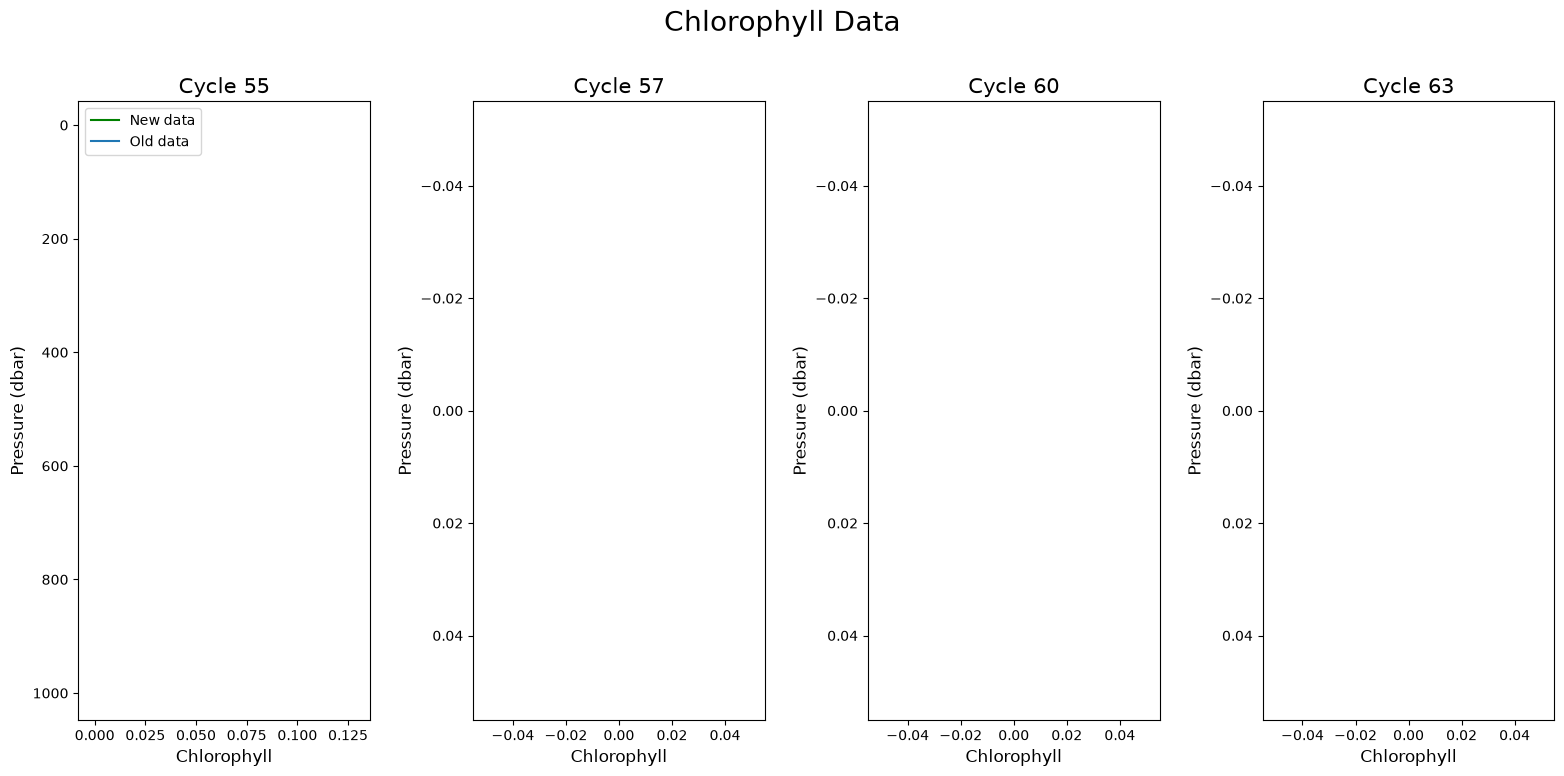

In [111]:
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(141)
ax.plot(new1['CHLA_ADJUSTED'], new1['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old1['CHLA_ADJUSTED'], old1['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
# ax.set_xlim(-0.1, 1.5)
# ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 55',  fontsize =15)
ax.legend()

ax = fig.add_subplot(142)
ax.plot(new2['CHLA_ADJUSTED'], new2['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old2['CHLA_ADJUSTED'], old2['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
# ax.set_xlim(-0.1, 1.5)
# ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 57',  fontsize =15)

ax = fig.add_subplot(143)
ax.plot(new3['CHLA_ADJUSTED'], new3['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old3['CHLA_ADJUSTED'], old3['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
# ax.set_xlim(-0.1, 1.5)
# ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 60',  fontsize =15)

ax = fig.add_subplot(144)
ax.plot(new4['CHLA_ADJUSTED'], new4['PRES_ADJUSTED'], c ='g', label ='New data')
ax.plot(old4['CHLA_ADJUSTED'], old4['PRES_ADJUSTED'], label='Old data')
ax.invert_yaxis()
# ax.set_xlim(-0.1, 1.5)
# ax.set_ylim(300, -5)
ax.set_xlabel('Chlorophyll', fontsize =12)
ax.set_ylabel('Pressure (dbar)', fontsize =12)
ax.set_title('Cycle 63', fontsize =15)

fig.suptitle('Chlorophyll Data', fontsize = 20)
plt.tight_layout(pad=2)


## Using old code, datetime and season without season - didn't work

In [156]:
df_new['DATE']

0         2019-03-13 12:30:40.000000
1         2019-03-13 12:30:40.000000
2         2019-03-13 12:30:40.000000
3         2019-03-13 12:30:40.000000
4         2019-03-13 12:30:40.000000
                     ...            
110235           2026-01-24 02:47:00
110236           2026-01-24 02:47:00
110237           2026-01-24 02:47:00
110238           2026-01-24 02:47:00
110239           2026-01-24 02:47:00
Name: DATE, Length: 110240, dtype: str

In [157]:
#convert to datetime
df_new['DATE'] = pd.to_datetime(df_new['DATE'],format = 'mixed')
#add year and month columns
df_new["year"] = df_new["DATE"].dt.year
df_new["month"] = df_new["DATE"].dt.month

# Define a season label: if month >=10 then season = year-year+1, else if month <=3 then season = (year-1)-year
def assign_season(row):
    m = row["month"]
    y = row["year"]
    if m >= 8:         # Aug, Sept, Oct, Nov, Dec
        return f"{y}-{y+1}"
    elif m <= 4:        # Jan, Feb, Mar
        return f"{y-1}-{y}"
    else:
        return f"{y}"   # outside the austral productive season (Apr-Sep)

#subset data with good QC only
qc_flags = [1,2,8]
df_new_season = df_new[df_new['CHLA_ADJUSTED_QC'].isin(qc_flags) & df_new['BBP700_ADJUSTED_QC'].isin(qc_flags) & df_new['DOXY_ADJUSTED_QC'].isin(qc_flags) & df_new['PSAL_ADJUSTED_QC'].isin(qc_flags)]

df_new_season["season"] = df_new.apply(assign_season, axis=1)

df_new_season['DATE']

1591    2020-01-05 17:06:37.001832
1594    2020-01-05 17:06:37.001832
1598    2020-01-05 17:06:37.001832
1601    2020-01-05 17:06:37.001832
1605    2020-01-05 17:06:37.001832
                   ...            
55629   2024-03-12 21:54:10.002331
55630   2024-03-12 21:54:10.002331
55631   2024-03-12 21:54:10.002331
55632   2024-03-12 21:54:10.002331
55633   2024-03-12 21:54:10.002331
Name: DATE, Length: 8166, dtype: datetime64[us]

In [158]:
def subset_yr(df, yr1,yr2):
    
    subset = df[df['year'].isin([yr1,yr2])]
    # add subset by the productive months
    # subset = subset[subset['month'].isin([1,2,3,4,8,9, 10,11,12])]
    
    return subset

df_new_yr = subset_yr(df_new_season,2014,2015)
df_new_yr

,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,NITRATE_ADJUSTED_QC,NITRATE_ADJUSTED_ERROR,PH_IN_SITU_TOTAL,PH_IN_SITU_TOTAL_QC,PH_IN_SITU_TOTAL_ADJUSTED,PH_IN_SITU_TOTAL_ADJUSTED_QC,PH_IN_SITU_TOTAL_ADJUSTED_ERROR,year,month,season


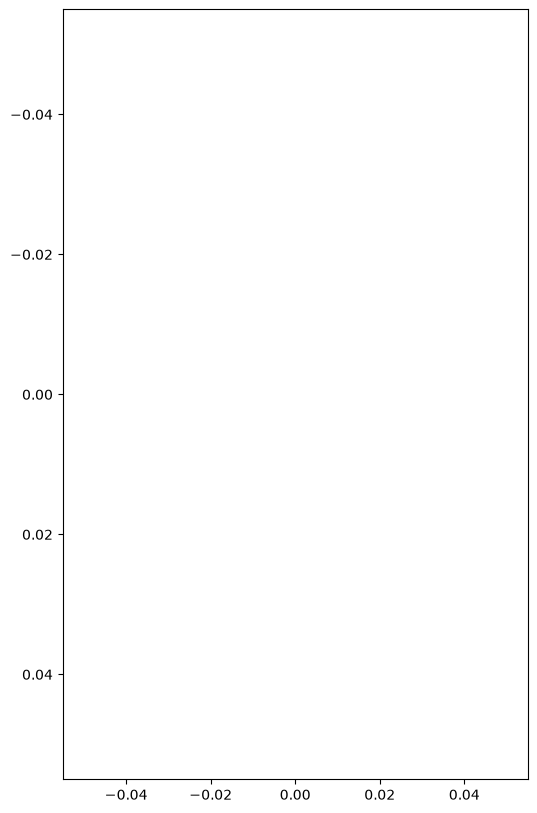

In [159]:
def chla_comp(df, WMOID, cycle):

    df = df[df['WMOID'].isin([WMOID])]
    df = df[df['CYCLE_NUMBER'].isin([cycle])]

    df['DATE'] = pd.to_datetime(df['DATE'])
    date_nums = mdates.date2num(df['DATE'])

    fig = plt.figure(figsize=(6, 10))

    ax = fig.add_subplot(111)
    ax.plot(df.loc[df['CYCLE_NUMBER'] == 41, 'CHLA_ADJUSTED'], df.loc[df['CYCLE_NUMBER'] == 41, 'PRES_ADJUSTED'])
    ax.invert_yaxis()

    plt.show()

chla_comp(df=df_new, WMOID=3902129, cycle=41)
